In [1]:
import numpy as np
import scipy as sp
import scipy.sparse, scipy.io, scipy.optimize
from scipy.special import expit

import matplotlib.pyplot as plt
import matplotlib as mpl
import time
%matplotlib inline

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a', # Color blind color cycle
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=CB_color_cycle) 

clip_01 = lambda M : np.clip(M, a_min=0, a_max=1)

from DataPreprocess import *

In [2]:
# adj = read_CAHepPh(ca_hepph_path='./data/CA-HepPh.txt')
# adj = read_cora(content_path="./data/cora/cora.content", cites_path="./data/cora/cora.cites")
adj = read_CAGrQc(ca_grqc_path="./data/ca-GrQc.txt")

Shape: (5241, 5241) nnz = 28968


In [3]:
def lpca_loss(factors, adj_s, rank): # adj_s = shifted adj with -1's and +1's
    n_row, n_col = adj_s.shape
    U = factors[:n_row*rank].reshape(n_row, rank)
    V = factors[n_row*rank:].reshape(rank, n_col)
    logits = U @ V
    prob_wrong = expit(-logits * adj_s)
    loss = (np.logaddexp(0,-logits*adj_s)).sum()# / n_element    
    U_grad = -(prob_wrong * adj_s) @ V.T# / n_element
    V_grad = -U.T @ (prob_wrong * adj_s)# / n_element
    print(loss)
    return loss, np.concatenate((U_grad.flatten(), V_grad.flatten()))

save_interval = 500 # the number of iterations after which to save the embeddings

def callback_recm(x_i): # prints the loss and periodically saves the factors
    global iter_num
    iter_num += 1
    if iter_num % save_interval == 0:
        global factors, n_row, n_col, rank
        factors = x_i
        U = factors[:n_row*rank].reshape(n_row, rank)
        V = factors[n_row*rank:].reshape(rank, n_col)
        frob_error_norm = np.linalg.norm(clip_01(U@V) - adj) / sp.sparse.linalg.norm(adj)
        print(iter_num, "Frob_error_norm: ", frob_error_norm)
        
# generate a rank k TSVD factorization of a small sparse matrix adj
def factor_TSVD(adj, k):
    w, v = np.linalg.eigh(np.array(adj.todense()))
    order = np.argsort(np.abs(w))[::-1]
    w = w[order[:k]]
    v = v[:,order[:k]]
    U_tsvd, V_tsvd = v * np.sqrt(np.abs(w))[None,:], (np.sign(w)*np.sqrt(np.abs(w)))[:,None] * v.T
    return U_tsvd, V_tsvd

# compute number of triangles in the subgraph induced by the first i nodes
def get_num_tri(i):
    global adj_recon_sort
    sub_adj = adj_recon_sort[:i+1,:i+1]
    num_tri = (1. * sub_adj @ sub_adj @ sub_adj).diagonal().sum() / 6
    return num_tri

In [4]:
def lpca_fit(adj, rank_value, maxiter=2000):
    global iter_num, factors, n_row, n_col, rank, frob_error_norm
    rank = rank_value
    n_row, n_col = adj.shape
    factors = -1+2*np.random.random(size=(np.sum(adj.shape)*rank)) # initalize uniformly on [-1,+1]
    iter_num = 0
    U = factors[:n_row*rank].reshape(n_row, rank)
    V = factors[n_row*rank:].reshape(rank, n_col)
    
    res = scipy.optimize.minimize(lpca_loss, x0=factors, 
                              args=(-1 + 2*np.array(adj.todense()), rank), jac=True, method='L-BFGS-B', 
                              callback=callback_recm, 
                              options={'maxiter':maxiter}
                             )
    factors = res.x
    U = res.x[:n_row*rank].reshape(n_row, rank)
    V = res.x[n_row*rank:].reshape(rank, n_col)
    frob_error_norm = np.linalg.norm(1.*(U @ V > 0) - adj) / sp.sparse.linalg.norm(adj)
    print("LPCA Frob norm error: ", frob_error_norm)
    return U, V

def tsvd_fit(adj, rank):
    U_tsvd, V_tsvd = factor_TSVD(adj, rank)
    frob_error_norm = np.linalg.norm(clip_01(U_tsvd@V_tsvd) - adj) / sp.sparse.linalg.norm(adj)
    print("TSVD Frob norm error: ", frob_error_norm)
    return U_tsvd, V_tsvd

In [5]:
def tri_reconstruction(U, V, n, skip_int):
    adj_recon = np.clip(U@V, a_min=0, a_max=1)
    deg_recon = np.array(adj_recon.sum(axis=1)).flatten()
    deg_order = np.argsort(deg_recon)
    deg_seq_recon = deg_recon[deg_order[::-skip_int]]

    adj_recon_sort = np.copy(adj_recon[np.ix_(deg_order, deg_order)])

    indices = np.arange(n)[::-skip_int]

    tri_seq_recon = []
    for i in indices:
        sub_adj = adj_recon_sort[:i+1, :i+1]
        num_tri = (sub_adj @ sub_adj @ sub_adj).diagonal().sum() / 6 / 1.0
        tri_seq_recon.append(num_tri)

    tri_seq_recon = np.array(tri_seq_recon)
    
    return deg_seq_recon, tri_seq_recon

In [6]:
U_lpca_16, V_lpca_16 = lpca_fit(adj, rank_value=16, maxiter=2000)

U_tsvd_16, V_tsvd_16 = tsvd_fit(adj, rank=16)
U_tsvd_128, V_tsvd_128 = tsvd_fit(adj, rank=128)

24233932.996525783
24156846.952914126
23855545.513297696
22761430.528700434
17902348.84726953
2227564.0222050096
1377280.091599105
457409.4892130637
375554.2189472939
305063.4651993067
257815.4873915337
286756.93514828675
236991.57062734078
245459.08083230097
224757.36495036056
215157.0744706448
207462.0064379346
198405.07597750836
189890.93343202418
184642.58983629823
181583.05906827722
175048.36122733622
169040.6932411455
160694.5979071091
153472.3006062901
146256.55356880417
135613.3088464932
128304.56302189751
121960.85852396091
117475.44984266035
110670.48596854808
103205.3591773121
98453.9828941047
94718.04506099416
92313.14340913366
88102.58755222455
85805.06669436656
82705.40393804185
76141.75455570486
72150.91694932924
69624.99471339448
67078.36854525271
64792.9885893854
59995.168848769405
57759.089492705025
55651.94630114714
52784.33339517111
50658.54447737134
47776.61639484388
45212.283904225726
42669.86785241934
40056.023309209726
37403.02918719547
35514.61996823463
34275.6

In [7]:
n = adj.shape[0]
skip_int = 100

deg_seq_recon_lpca_16, tri_seq_recon_lpca_16 = tri_reconstruction(U_lpca_16, V_lpca_16, n=n, skip_int=skip_int)
deg_seq_recon_tsvd_16, tri_seq_recon_tsvd_16 = tri_reconstruction(U_tsvd_16, V_tsvd_16, n=n, skip_int=skip_int)
deg_seq_recon_tsvd_128, tri_seq_recon_tsvd_128 = tri_reconstruction(U_tsvd_128, V_tsvd_128, n=n, skip_int=skip_int)

deg_true = np.array(adj.sum(axis=1)).flatten()
deg_order_true = np.argsort(deg_true)
deg_seq_true = deg_true[deg_order_true[::-skip_int]]
adj_recon_sort = np.copy(adj.todense()[np.ix_(deg_order_true, deg_order_true)])

indices = np.arange(n)[::-skip_int]

tri_seq_true = []
for i in indices:
    sub_adj = adj_recon_sort[:i+1, :i+1]
    num_tri = (sub_adj @ sub_adj @ sub_adj).diagonal().sum() / 6 / 1.0
    tri_seq_true.append(num_tri)

tri_seq_true = np.array(tri_seq_true)

Text(0.5, 1.0, 'ca-GrQc')

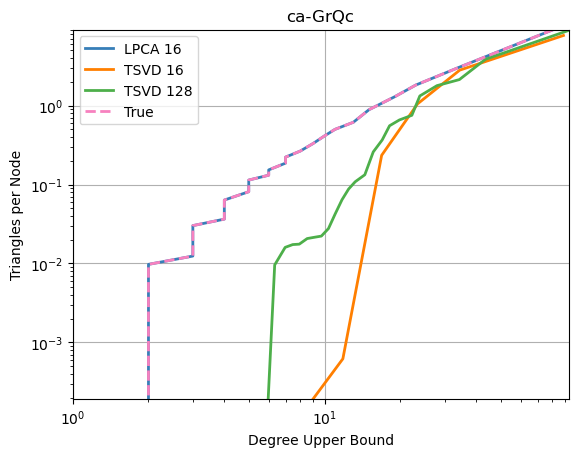

In [9]:
fig, ax = plt.subplots()
ax.semilogy(deg_seq_recon_lpca_16, tri_seq_recon_lpca_16 / n, label='LPCA 16', linewidth=2)
ax.semilogy(deg_seq_recon_tsvd_16, tri_seq_recon_tsvd_16 / n, label='TSVD 16', linewidth=2)
ax.semilogy(deg_seq_recon_tsvd_128, tri_seq_recon_tsvd_128 / n, label='TSVD 128', linewidth=2)
ax.semilogy(deg_seq_true, tri_seq_true / n, label='True', linestyle='--', linewidth=2)

ax.legend()
ax.grid()
ax.autoscale(enable=True, axis='x', tight=True)
ax.autoscale(enable=True, axis='y', tight=True)
ax.set_xlim(1,)
ax.set_ylim(1/n,)

ax.set_xscale('log')

ax.set_ylabel('Triangles per Node')
ax.set_xlabel('Degree Upper Bound')
ax.set_title('ca-GrQc')